# 06 — Modeling: Baselines, Model Comparison, Class Imbalance

**Goal:** find the best churn-ranking model honestly — proper baselines, identical
preprocessing for every candidate, stratified cross-validation on training data only, and
imbalance handling chosen on evidence.

**The evaluation protocol (the part that keeps us honest):**

1. One stratified 80/20 train/test split (`random_state=42`). **The test set is now locked
   away** — it is touched exactly once, at the very end, to report the final model's
   generalization. Every decision (model choice, imbalance strategy, hyperparameters,
   threshold) is made on cross-validated *training* data.
2. Preprocessing lives inside each model's `Pipeline` (`ColumnTransformer` → estimator), so
   every CV fold fits its encoders/scaler on that fold's training portion only. There is no
   preprocessed-then-split dataset anywhere in this project.
3. Stratified 5-fold CV: each fold preserves the 26.5% churn prevalence.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR, RANDOM_STATE
from src.evaluate import cv_compare
from src.feature_engineering import FEATURES_DATA_FILE
from src.train import build_preprocessor, candidate_models, split_data

BLUE, ORANGE, INK, INK2, MUTED, GRID, BASELINE_C = (
    "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": BASELINE_C, "axes.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 110,
})

df = pd.read_csv(FEATURES_DATA_FILE)
X_train, X_test, y_train, y_test = split_data(df)
print(f"train: {X_train.shape[0]:,} rows, churn {y_train.mean():.2%}")
print(f"test:  {X_test.shape[0]:,} rows, churn {y_test.mean():.2%}  <- locked away until the end")

train: 5,634 rows, churn 26.54%
test:  1,409 rows, churn 26.54%  <- locked away until the end


## 1. Metrics, in churn terms — decided before looking at any scores

For the churn (positive) class, at a given decision threshold:

- **Accuracy** — fraction of all customers labeled correctly. *Weakest metric here:* predicting
  "stays" for everyone scores 73.5% while being useless. Reported, never optimized.
- **Precision** — of customers we flag as churn risks, how many actually churn. Low precision =
  retention budget sprayed at loyal customers.
- **Recall** — of customers who actually churn, how many we catch. Low recall = churners walk
  out the door unflagged. **The business-critical metric for retention.**
- **F1** — harmonic mean of the two; a single balance number with no business weighting.
- **ROC-AUC** — threshold-free ranking quality: probability a random churner scores above a
  random non-churner. Good for model comparison; can flatter under imbalance.
- **PR-AUC** (average precision) — like ROC-AUC but focused on the positive class; its floor is
  the prevalence (0.265), not 0.5. **Our primary model-selection metric**, because the product
  decision is "rank customers for a limited retention budget," which is exactly what the
  precision-recall trade-off describes.

**Error costs (framing, not numbers):** a false positive wastes one retention offer; a false
negative loses a customer's future revenue. The dataset contains no cost data, so *which is
costlier is an assumption we defer* to the scenario analysis (notebook on retention simulation),
where it is explicit and adjustable. Directionally, retention offers are usually far cheaper
than customer replacement — **industry assumption, labeled as such** — which is why recall gets
priority in threshold selection later.

## 2. The preprocessing pipeline

One shared `ColumnTransformer` (defined in [`src/train.py`](../src/train.py)) for every model:
`StandardScaler` on the 4 numerics (logistic regression needs comparable scales; trees are
scale-invariant and unharmed), `OneHotEncoder(drop="if_binary", handle_unknown="ignore")` on the
18 categoricals (single indicator for binary columns → cleaner coefficients; unseen categories
at scoring time encode as zeros instead of crashing).

In [2]:
pre = build_preprocessor()
pre.fit(X_train)   # fit here only to inspect dimensionality; CV refits per fold
names = pre.get_feature_names_out()
print(f"{X_train.shape[1]} input features -> {len(names)} model inputs after one-hot")
print(names)

22 input features -> 33 model inputs after one-hot
['tenure' 'MonthlyCharges' 'num_protective' 'num_streaming' 'gender_Male'
 'SeniorCitizen_Yes' 'Partner_Yes' 'Dependents_Yes' 'PhoneService_Yes'
 'MultipleLines_Yes' 'InternetService_DSL' 'InternetService_Fiber optic'
 'InternetService_No' 'OnlineSecurity_Yes' 'OnlineBackup_Yes'
 'DeviceProtection_Yes' 'TechSupport_Yes' 'StreamingTV_Yes'
 'StreamingMovies_Yes' 'Contract_Month-to-month' 'Contract_One year'
 'Contract_Two year' 'PaperlessBilling_Yes'
 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check' 'tenure_group_0-6' 'tenure_group_13-24'
 'tenure_group_25-48' 'tenure_group_49+' 'tenure_group_7-12'
 'auto_pay_Yes']


## 3. Why baselines?

A model is only "good" relative to what naive strategies achieve. The **majority-class dummy**
(always "stays") anchors the floor: 73.5% accuracy, 0 recall, ROC-AUC 0.5, PR-AUC = prevalence.
Any candidate must beat it *by a margin that justifies its complexity*. **Logistic regression**
is the ML baseline: linear, fast, interpretable — the model to beat before anything fancier
earns its keep.

## 4. Cross-validated comparison — five algorithms + dummy

Lineup: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting (sklearn), and
**XGBoost** as the required external strong learner (industry-standard regularized boosting;
also brings `scale_pos_weight` for the imbalance comparison). All defaults except sensible
capacity settings (300 trees for the ensembles) — tuning comes later, on the strongest
candidates only.

*Note on warnings below:* the dummy baseline never predicts the positive class, so its precision
is 0/0 — sklearn warns and scores it 0. Expected, not suppressed.

In [3]:
models = candidate_models(class_weighted=False)
results = cv_compare(models, X_train, y_train)

mean_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
display = results[mean_cols].round(3).copy()
display["roc_auc ± std"] = (results["roc_auc"].round(3).astype(str) + " ± "
                            + results["roc_auc_std"].round(3).astype(str))
display

/Users/sorani/telco-customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sorani/telco-customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sorani/telco-customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

/Users/sorani/telco-customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,accuracy,precision,recall,f1,roc_auc,pr_auc,roc_auc ± std
model,,,,,,,
Logistic Regression,0.808,0.673,0.535,0.596,0.848,0.665,0.848 ± 0.011
Gradient Boosting,0.805,0.669,0.524,0.587,0.847,0.665,0.847 ± 0.012
XGBoost,0.790,0.627,0.513,0.565,0.828,0.629,0.828 ± 0.01
Random Forest,0.786,0.627,0.485,0.546,0.821,0.607,0.821 ± 0.014
Decision Tree,0.726,0.484,0.495,0.489,0.653,0.375,0.653 ± 0.018
Majority baseline,0.735,0.000,0.000,0.000,0.500,0.265,0.5 ± 0.0


**Reading the table (5-fold CV means on training data):**

1. **Logistic regression leads** — PR-AUC 0.665, ROC-AUC 0.848 ± 0.011 — with gradient boosting
   statistically tied (0.665 / 0.847 ± 0.012; the gap is far inside one fold-std). On ~5,600
   training rows with strong, well-understood main effects and limited interaction depth, the
   linear model captures nearly all the signal the boosters find.
2. **XGBoost (0.828) and random forest (0.821) trail** at default settings — tuning may close
   some of the gap; we'll see.
3. **The unconstrained decision tree collapses** (ROC-AUC 0.653, PR-AUC 0.375): grown to purity
   it memorizes training folds — the textbook overfitting demonstration, and the reason the
   ensembles exist at all.
4. Everything beats the dummy by a wide margin, so modeling is adding real value over
   base rates.
5. **Default-threshold recall is poor everywhere** (0.49–0.54): at 0.5 these models miss almost
   half the churners. For a retention use case that's unacceptable — which is exactly why the
   imbalance section and threshold optimization exist.

## 5. Class imbalance: strategy comparison

The 26.5/73.5 split is *moderate* — not the 1-in-1000 regime. Candidate remedies:

| Strategy | Mechanism | Verdict for this project |
|---|---|---|
| Class weights | loss reweighted ~2.77:1 toward churners | **Tested below** — zero-cost, no data surgery |
| Threshold adjustment | keep model, move the decision cutoff | **Adopted later** — most transparent control |
| SMOTE / resampling | synthesize minority samples | **Rejected — reasoning below** |

**Why not SMOTE here?** (a) At 26.5% prevalence there's no minority-starvation problem for it to
fix. (b) Its linear interpolation is dubious in a mostly one-hot space — "0.4 × Fiber optic" is
not a customer (SMOTENC exists, but adds a dependency for a benefit nobody has demonstrated at
this imbalance level). (c) It must be re-run inside every CV fold (via imblearn's pipeline) to
avoid leaking synthetic copies of validation rows into training — an easy trap that argues for
the simpler tool. (d) Class weights already deliver the same recall-precision movement with no
synthetic data at all. If weights and thresholding had failed, SMOTE would be the next
experiment — decision on evidence, not fashion.

In [4]:
weighted = cv_compare(candidate_models(class_weighted=True), X_train, y_train)
comparison = pd.concat({"unweighted": results[mean_cols], "class-weighted": weighted[mean_cols]},
                       axis=1).round(3)
comparison.dropna()

unweighted                                         \
                      accuracy precision recall     f1 roc_auc pr_auc   
model                                                                   
Logistic Regression      0.808     0.673  0.535  0.596   0.848  0.665   
XGBoost                  0.790     0.627  0.513  0.565   0.828  0.629   
Random Forest            0.786     0.627  0.485  0.546   0.821  0.607   
Decision Tree            0.726     0.484  0.495  0.489   0.653  0.375   

                    class-weighted                                         
                          accuracy precision recall     f1 roc_auc pr_auc  
model                                                                      
Logistic Regression          0.750     0.519  0.794  0.627   0.848  0.663  
XGBoost                      0.772     0.558  0.674  0.610   0.824  0.624  
Random Forest                0.774     0.564  0.647  0.603   0.824  0.605  
Decision Tree                0.731     0.493  0.476  0.484   0.650  0.375

**The decisive observation:** class weighting moves logistic regression's recall from
**0.535 → 0.794** while precision falls 0.673 → 0.519 — but **ROC-AUC is unchanged (0.848) and
PR-AUC is unchanged (0.665 → 0.663)**. The same holds for XGBoost and random forest.

That is the whole story of class weights in one line: *they don't make the model rank customers
any better — they just relocate the default 0.5 threshold to a more recall-friendly operating
point.* Since threshold placement is a business decision we want to make explicitly (with a
precision-recall curve in hand), we get the same effect with more control by **keeping
unweighted models and tuning the threshold directly** — the next notebook section.

(Class weights remain the right tool when retraining is cheap and you want sane defaults; the
point is that they are not *additional* ranking power.)

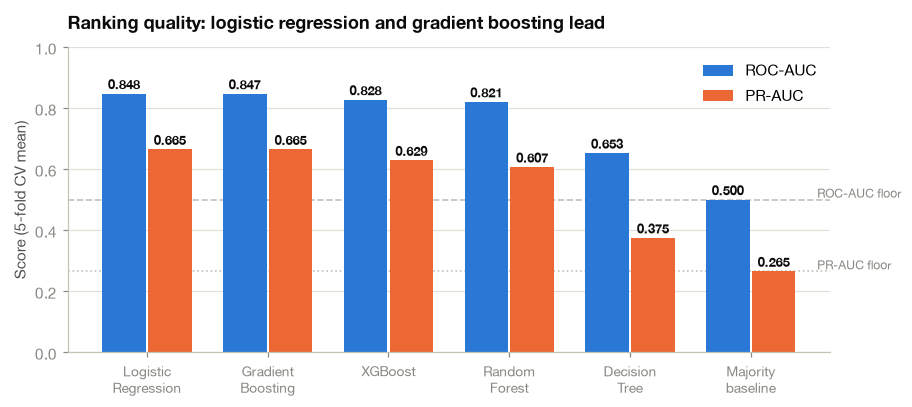

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
plot_df = results.loc[["Logistic Regression", "Gradient Boosting", "XGBoost",
                       "Random Forest", "Decision Tree", "Majority baseline"]]
x = np.arange(len(plot_df))
ax.bar(x - 0.19, plot_df["roc_auc"], 0.36, label="ROC-AUC", color=BLUE)
ax.bar(x + 0.19, plot_df["pr_auc"], 0.36, label="PR-AUC", color=ORANGE)
ax.axhline(0.5, color=BASELINE_C, ls="--", lw=1.1, zorder=0)
ax.axhline(0.265, color=BASELINE_C, ls=":", lw=1.1, zorder=0)
ax.text(len(plot_df) - 0.45, 0.507, "ROC-AUC floor", color=MUTED, fontsize=8)
ax.text(len(plot_df) - 0.45, 0.272, "PR-AUC floor", color=MUTED, fontsize=8)
for xi, (r, p) in zip(x, zip(plot_df["roc_auc"], plot_df["pr_auc"])):
    ax.text(xi - 0.19, r + 0.015, f"{r:.3f}", ha="center", fontsize=8.5, color=INK, fontweight="bold")
    ax.text(xi + 0.19, p + 0.015, f"{p:.3f}", ha="center", fontsize=8.5, color=INK, fontweight="bold")
ax.set_xticks(x, ["Logistic\nRegression", "Gradient\nBoosting", "XGBoost",
                  "Random\nForest", "Decision\nTree", "Majority\nbaseline"], fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score (5-fold CV mean)")
ax.set_title("Ranking quality: logistic regression and gradient boosting lead", loc="left", pad=12)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "11_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Interim conclusions (Part 1)

1. **Candidates for tuning:** logistic regression and gradient boosting (tied leaders), plus
   XGBoost (strongest tunable headroom). Random forest and the lone decision tree are dropped.
2. **Imbalance strategy:** unweighted models + explicit threshold optimization; SMOTE rejected
   with reasons; class weights understood as threshold-relocation, not extra skill.
3. **The test set remains untouched.** Tuning (GridSearchCV), threshold selection, and the
   single final test evaluation follow in Part 2 below.


---
# Part 2 — Hyperparameter Tuning, Threshold Optimization, Final Test Evaluation

## 6. Hyperparameter tuning (GridSearchCV, training data only)

The three finalists get grid searches with **`scoring="average_precision"` (PR-AUC)** — the
pre-committed selection metric — under the same stratified 5-fold CV. The test set plays no part.
Grid sizes are deliberate: logistic regression has essentially one knob (regularization `C`);
the boosters get capacity/shrinkage/subsampling grids around sensible defaults (36 and 48
combinations — enough to find the plateau, not an exhaustive fishing expedition).

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from src.evaluate import make_cv
from src.train import make_pipeline

cv = make_cv()
grids = {
    "Logistic Regression": (
        make_pipeline(LogisticRegression(max_iter=2000)),
        {"model__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]},
    ),
    "Gradient Boosting": (
        make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
        {"model__n_estimators": [100, 200, 300],
         "model__learning_rate": [0.03, 0.05, 0.1],
         "model__max_depth": [2, 3],
         "model__subsample": [0.8, 1.0]},
    ),
    "XGBoost": (
        make_pipeline(XGBClassifier(tree_method="hist", eval_metric="logloss",
                                    random_state=RANDOM_STATE, n_jobs=-1)),
        {"model__n_estimators": [200, 400],
         "model__learning_rate": [0.03, 0.1],
         "model__max_depth": [2, 3, 4],
         "model__subsample": [0.8, 1.0],
         "model__colsample_bytree": [0.8, 1.0]},
    ),
}

tuned = {}
for name, (pipe, grid) in grids.items():
    gs = GridSearchCV(pipe, grid, scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc"},
                      refit="pr_auc", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    i = gs.best_index_
    tuned[name] = {
        "best_params": {k.replace("model__", ""): v for k, v in gs.best_params_.items()},
        "cv_pr_auc": gs.cv_results_["mean_test_pr_auc"][i],
        "cv_pr_auc_std": gs.cv_results_["std_test_pr_auc"][i],
        "cv_roc_auc": gs.cv_results_["mean_test_roc_auc"][i],
        "n_combos": len(gs.cv_results_["params"]),
    }
    print(f"{name}: best {tuned[name]['best_params']}")
    print(f"  CV PR-AUC {tuned[name]['cv_pr_auc']:.4f} ± {tuned[name]['cv_pr_auc_std']:.4f} | "
          f"CV ROC-AUC {tuned[name]['cv_roc_auc']:.4f} | {tuned[name]['n_combos']} combos tested")

Logistic Regression: best {'C': 1.0}
  CV PR-AUC 0.6649 ± 0.0144 | CV ROC-AUC 0.8477 | 7 combos tested


Gradient Boosting: best {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  CV PR-AUC 0.6682 ± 0.0200 | CV ROC-AUC 0.8496 | 36 combos tested


XGBoost: best {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  CV PR-AUC 0.6690 ± 0.0207 | CV ROC-AUC 0.8495 | 48 combos tested


### Model selection — and why it is *not* the highest raw number

| Model | Best params | CV PR-AUC | CV ROC-AUC |
|---|---|---|---|
| XGBoost | lr=0.03, depth=3, n=200, subsample/colsample=0.8 | 0.6690 ± 0.0207 | 0.8495 |
| Gradient Boosting | lr=0.03, depth=3, n=200, subsample=0.8 | 0.6682 ± 0.0200 | 0.8496 |
| **Logistic Regression (selected)** | C=1.0 | 0.6649 ± 0.0144 | 0.8477 |

The spread between best and worst is **0.004 PR-AUC — a fifth of one fold's standard
deviation**. These models are statistically indistinguishable on ranking quality; tuning bought
the boosters almost nothing (XGBoost +0.002 over its default) and logistic regression literally
nothing (best C is the default). Two readings worth internalizing: the dataset's signal is
dominated by additive main effects, and grid search cannot conjure interactions that aren't
there.

**Selected final model: logistic regression (C = 1.0)**, on secondary criteria that matter when
the primary metric ties:

1. **Stability** — lowest fold variance (±0.014 vs ±0.021).
2. **Interpretability** — coefficients are log-odds a retention team can read; explanations in
   notebook 07 need no approximation layer.
3. **Calibration** — its probabilities can be used as probabilities (verified on test below),
   which the risk-tier system depends on.
4. **Operational cost** — trivial retraining, no compiled dependency, one hyperparameter.

Choosing XGBoost for +0.004±0.02 would be complexity without payoff — the exact trade rule 11
of the project brief warns about.

## 7. Threshold optimization

Nothing is sacred about 0.50 — it silently assumes both error types cost the same, and Part 1
showed it misses ~47% of churners. The analysis: sweep the threshold over **out-of-fold training
probabilities** (each row predicted by a model that never trained on it — using refit-on-train
probabilities here would flatter precision/recall; using test would be tuning on the test set).

**Cost framing, stated honestly:** the dataset prices neither error, so we adopt the *neutral*
operating point — maximum F1, where precision and recall are equally weighted — and document a
recall-first alternative. The retention-scenario notebook makes costs an explicit adjustable
assumption; if the business priced a missed churner at, say, 5× a wasted offer, the threshold
would shift further left, and the framework below shows exactly how.

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

from src.config import DECISION_THRESHOLD
from src.train import final_model

final_pipe = final_model()   # LR, C=1.0 — as selected above
proba_oof = cross_val_predict(final_pipe, X_train, y_train, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, proba_oof)
f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)

ix = int(np.argmax(f1[:-1]))
t_star = float(thr[ix])
mask = rec[:-1] >= 0.80
jx = int(np.argmax(prec[:-1] * mask))

ops = pd.DataFrame([
    {"operating point": "default 0.50", "threshold": 0.50,
     "precision": prec[np.searchsorted(thr, 0.50)], "recall": rec[np.searchsorted(thr, 0.50)],
     "f1": f1[np.searchsorted(thr, 0.50)]},
    {"operating point": "max F1 (ADOPTED)", "threshold": t_star,
     "precision": prec[ix], "recall": rec[ix], "f1": f1[ix]},
    {"operating point": "recall >= 0.80", "threshold": float(thr[jx]),
     "precision": prec[jx], "recall": rec[jx], "f1": f1[jx]},
]).set_index("operating point").round(3)
print(f"Adopted threshold (max F1 on out-of-fold train): {t_star:.3f}")
assert abs(t_star - DECISION_THRESHOLD) < 5e-3, "config constant matches the analysis"
ops

Adopted threshold (max F1 on out-of-fold train): 0.338


,threshold,precision,recall,f1
operating point,,,,
default 0.50,0.500,0.673,0.535,0.596
max F1 (ADOPTED),0.338,0.571,0.726,0.639
recall >= 0.80,0.261,0.520,0.800,0.630


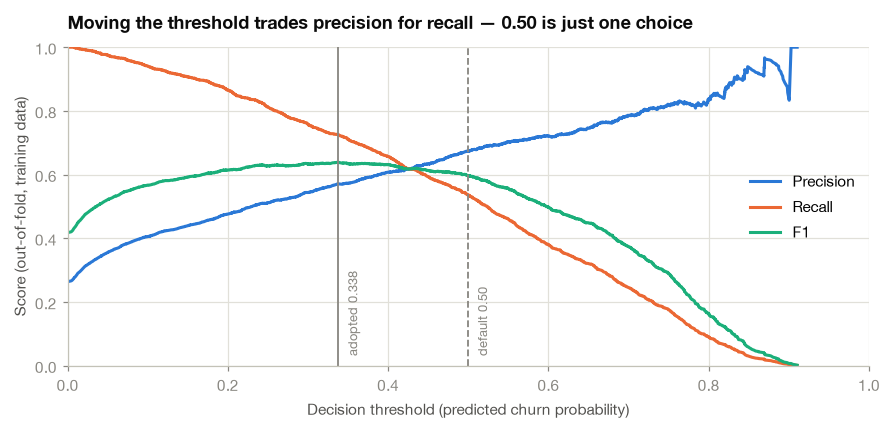

In [8]:
AQUA = "#1baf7a"
fig, ax = plt.subplots(figsize=(8.2, 4))
ts = thr
ax.plot(ts, prec[:-1], color=BLUE, lw=2, label="Precision")
ax.plot(ts, rec[:-1], color=ORANGE, lw=2, label="Recall")
ax.plot(ts, f1[:-1], color=AQUA, lw=2, label="F1")
for t, style, lbl in [(t_star, "-", f"adopted {t_star:.3f}"), (0.5, "--", "default 0.50")]:
    ax.axvline(t, color=MUTED, ls=style, lw=1.2)
    ax.text(t + 0.008, 0.03, lbl, color=MUTED, fontsize=8.5, rotation=90, va="bottom")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Decision threshold (predicted churn probability)")
ax.set_ylabel("Score (out-of-fold, training data)")
ax.set_title("Moving the threshold trades precision for recall — 0.50 is just one choice",
             loc="left", pad=12)
ax.legend(frameon=False, loc="center right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "12_threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the trade-off:** moving 0.50 → 0.338 lifts recall 0.535 → 0.726 (we catch
~73% of churners instead of ~54%) while precision falls 0.673 → 0.571 (57% of flags are real
churners instead of 67%). In customer terms per 1,000 churners: ~190 additional churners
caught, at the cost of more non-churners receiving (cheap) retention outreach. Under the
labeled assumption that a missed churner costs more than a wasted offer, that trade is
favorable; the scenario notebook quantifies it under explicit cost settings.

## 8. The final test evaluation — one pass, everything reported

The moment the whole protocol protected: the selected pipeline (LR, C=1.0) is fit on the full
training set and evaluated **once** on the 1,409 held-out customers. Both the adopted and the
default threshold are reported from this single set of predictions — transparency, not a second
bite at tuning (the threshold was fixed *before* this cell from training data alone).

In [9]:
from src.evaluate import score_predictions

final_pipe.fit(X_train, y_train)
proba_test = final_pipe.predict_proba(X_test)[:, 1]

rows = {}
for label, t in [("default 0.50", 0.50), (f"adopted {t_star:.3f}", t_star)]:
    m = score_predictions(y_test, (proba_test >= t).astype(int), proba_test)
    cm = m.pop("confusion_matrix")
    rows[label] = {**m, "TN": cm[0, 0], "FP": cm[0, 1], "FN": cm[1, 0], "TP": cm[1, 1]}
test_results = pd.DataFrame(rows).T.round(3)
test_results

,accuracy,precision,recall,f1,roc_auc,pr_auc,TN,FP,FN,TP
default 0.50,0.801,0.660,0.513,0.577,0.845,0.65,936.0,99.0,182.0,192.0
adopted 0.338,0.775,0.558,0.730,0.633,0.845,0.65,819.0,216.0,101.0,273.0


**Generalization check — CV promised vs test delivered:** ROC-AUC 0.848 (CV) → **0.845**
(test); PR-AUC 0.665 (CV) → **0.650** (test, within one fold-std). No selection overfitting:
what cross-validation estimated is what the held-out data returned.

**The adopted operating point on test, in words:** of 374 actual churners, the model catches
**273 (recall 0.730)** and misses 101; of 489 customers it flags, 273 are real churners
(precision 0.558). Versus the default threshold, that's **81 additional churners caught** in
exchange for 117 more false alarms — the trade selected on training data, honored by the test
set almost exactly (train OOF predicted R=0.726/P=0.571; test delivered R=0.730/P=0.558).

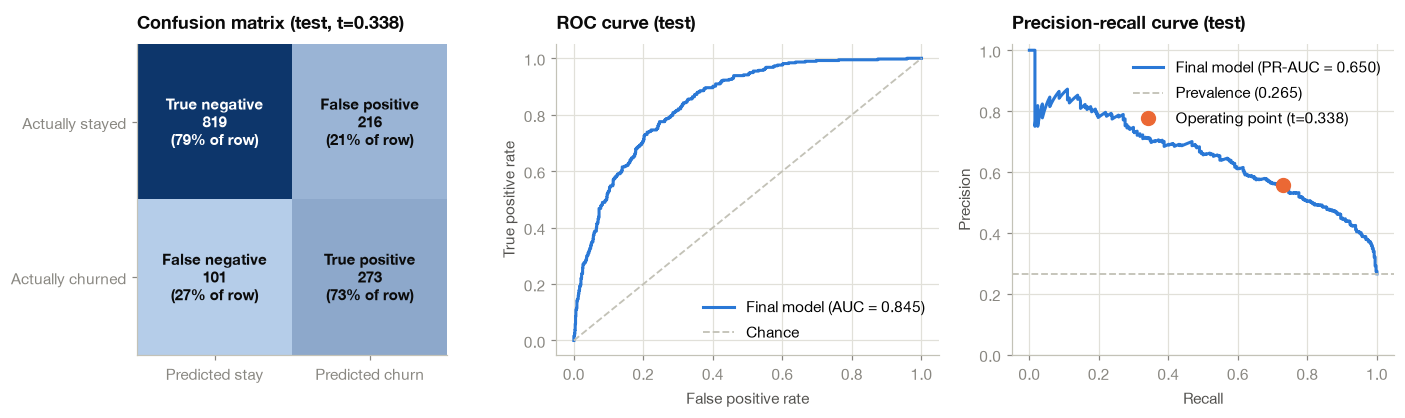

In [10]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve

y_pred = (proba_test >= t_star).astype(int)
cm = np.array([[rows[f"adopted {t_star:.3f}"]["TN"], rows[f"adopted {t_star:.3f}"]["FP"]],
               [rows[f"adopted {t_star:.3f}"]["FN"], rows[f"adopted {t_star:.3f}"]["TP"]]])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9))

# -- confusion matrix --
ax = axes[0]
seq = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#0d366b"])
ax.imshow(cm, cmap=seq, vmin=0, vmax=cm.max())
labels = [["True negative", "False positive"], ["False negative", "True positive"]]
for i in range(2):
    for j in range(2):
        share = cm[i, j] / cm[i].sum()
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}\n({share:.0%} of row)",
                ha="center", va="center", fontsize=9.5, fontweight="bold",
                color="white" if cm[i, j] > cm.max() * 0.55 else INK)
ax.set_xticks([0, 1], ["Predicted stay", "Predicted churn"])
ax.set_yticks([0, 1], ["Actually stayed", "Actually churned"])
ax.set_title(f"Confusion matrix (test, t={t_star:.3f})", loc="left", pad=10)
ax.grid(visible=False)

# -- ROC curve --
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
ax.plot(fpr, tpr, color=BLUE, lw=2, label=f"Final model (AUC = {rows['default 0.50']['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color=BASELINE_C, ls="--", lw=1.2, label="Chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve (test)", loc="left", pad=10)
ax.legend(frameon=False, loc="lower right")

# -- PR curve --
ax = axes[2]
p_t, r_t, _ = precision_recall_curve(y_test, proba_test)
ax.plot(r_t, p_t, color=BLUE, lw=2, label=f"Final model (PR-AUC = {rows['default 0.50']['pr_auc']:.3f})")
ax.axhline(y_test.mean(), color=BASELINE_C, ls="--", lw=1.2, label=f"Prevalence ({y_test.mean():.3f})")
ax.plot(rows[f"adopted {t_star:.3f}"]["recall"], rows[f"adopted {t_star:.3f}"]["precision"],
        "o", color=ORANGE, ms=9, label=f"Operating point (t={t_star:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_ylim(0, 1.02)
ax.set_title("Precision-recall curve (test)", loc="left", pad=10)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "13_test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### Calibration — can the probabilities be trusted as probabilities?

The risk-tier system (notebook 07) bins customers by predicted probability, which only makes
sense if a "0.7" really churns ~70% of the time. Decile check on the test set:

In [11]:
cal = (pd.DataFrame({"pred": proba_test, "actual": y_test.values})
       .groupby(pd.qcut(proba_test, 10, duplicates="drop"), observed=True)
       .agg(mean_predicted=("pred", "mean"), actual_churn_rate=("actual", "mean"), n=("actual", "count"))
       .round(3))
cal

,mean_predicted,actual_churn_rate,n
"(0.0033499999999999997, 0.0136]",0.009,0.014,141
"(0.0136, 0.0319]",0.022,0.007,141
"(0.0319, 0.0585]",0.044,0.043,141
"(0.0585, 0.111]",0.083,0.099,141
"(0.111, 0.186]",0.149,0.149,141
"(0.186, 0.281]",0.230,0.271,140
"(0.281, 0.393]",0.334,0.340,141
"(0.393, 0.508]",0.454,0.411,141
"(0.508, 0.677]",0.591,0.574,141
"(0.677, 0.908]",0.765,0.745,141


Predicted and actual rates track closely across all ten deciles (e.g. the top decile
predicts 0.765 and shows 0.745 actual churn) — logistic regression's probabilities are honest
out of the box, no recalibration layer needed. This is a quiet advantage over margin-based
models and part of why LR won the selection.

## 9. Save the final model

`python -m src.train` reproduces this artifact from the raw CSV; the notebook saves the same
object for immediate downstream use (pipeline + threshold + feature list, versioned together
so the app can never mix a threshold with the wrong model).

In [12]:
import joblib

from src.config import FINAL_MODEL_FILE
from src.feature_engineering import FEATURE_COLUMNS

FINAL_MODEL_FILE.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": final_pipe, "threshold": t_star,
             "feature_columns": FEATURE_COLUMNS, "n_train": len(X_train)}, FINAL_MODEL_FILE)
print(f"saved -> {FINAL_MODEL_FILE.name}")

saved -> final_churn_pipeline.joblib


## Final model card

| | |
|---|---|
| **Model** | Logistic regression (C=1.0) in a preprocessing pipeline (scaler + one-hot) |
| **Decision threshold** | 0.338 (max-F1 on out-of-fold training predictions) |
| **Test ROC-AUC / PR-AUC** | 0.845 / 0.650 |
| **Test recall / precision @ threshold** | 0.730 / 0.558 |
| **Strengths** | Stable across folds; readable coefficients; well-calibrated probabilities; trivially retrainable |
| **Weaknesses** | Cannot express feature interactions beyond those engineered by hand; performance ceiling shared with all models on this feature set (~0.85 AUC) |
| **Operational limitations** | Trained on a single snapshot — no temporal validation possible; needs drift monitoring and periodic retraining in production; threshold should be revisited when real cost data exists |
